# ***Handwritten Digit Recognition***
---

Handwritten digit recognition is a fundamental problem in computer vision and machine learning, involving the classification of images of handwritten digits (0-9). The MNIST dataset, containing 70,000 grayscale images of size 28x28 pixels, serves as a standard benchmark for evaluating classification algorithms.

> Handwritten digit recognition plays a vital role in many industries, including postal mail sorting, bank cheque processing, and automated form data entry. It is also used in number plate recognition for traffic control, mobile banking check deposits, and security systems like fingerprint and retinal scanners. Accurate and reliable digit recognition is essential for efficient automation and error reduction in these applications.


This project focuses on applying simple machine learning models—specifically, fully connected Artificial Neural Networks (ANNs), K-Nearest Neighbors (KNN), and Support Vector Machines (SVM)—to classify handwritten digits from the MNIST dataset. The objective is to build a foundational understanding of different classification techniques, including neural networks and classical machine learning algorithms, and to compare their performance on image data.









## Importing Dependencies

In [ ]:
import numpy as np
%matplotlib widget
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow/Keras for Neural Networks
import tensorflow
import keras
from tensorflow.keras.models import Sequential
from keras import Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Sklearn for KNN, SVM, and Evaluation
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Loading the Dataset
The MNIST dataset can be loaded conveniently with the help of the Keras deep learning library. Therefore, using the below function makes it simple to import the dataset.

```
# mnist.load_data()
```



In [ ]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

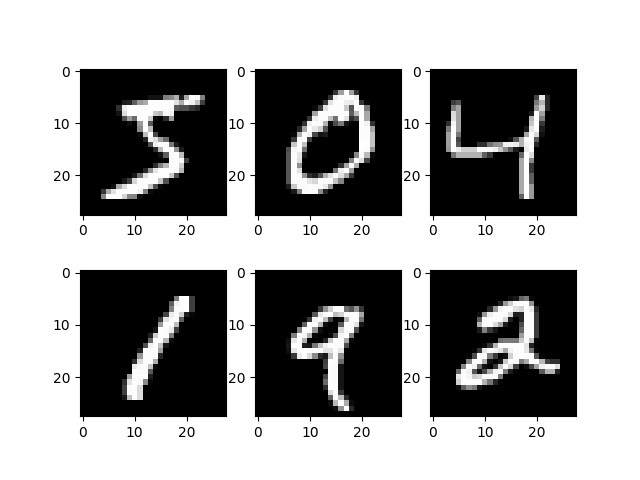

In [ ]:
#Visualize Sample Data
for i in range(6):
  plt.subplot(int('23' + str(i+1)))
  plt.imshow(x_train[i], cmap=plt.get_cmap('gray'))
plt.show()



> The handwritten digit dataset from MNIST, consists **70,000** grayscale pictures of handwritten numbers from **0 to 9** make up this collection. These are divided into **10,000** testing images and **60,000** training images. Due to the **28x28 pixel** size of each image, each sample has a **2D** array format. To represent the actual digit shown in the picture, the corresponding labels are integers ranging from **0 to 9**.



## Data Pre-processing

**Reshaping the dimensions of image from 28x28 → 784**

In [ ]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

**Normalizing the image to [0,1] range**

Convertng pixel values from [0, 255] → [0.0, 1.0] for faster convergence

In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

**Split Validation Set**

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

## Building the Models

### **Model 1: Neural Network (ANN)**

In [ ]:
# Initializing the ANN model
ann_model = Sequential([
    Input(shape=(784,)),  # <- since 28*28 = 784
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')  # 10 classes for digits 0–9
])

In [ ]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# EarlyStopping
es = EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=4, verbose=1)

# ModelCheckpoint
mc = ModelCheckpoint("./model.keras", monitor='val_accuracy', verbose=1, save_best_only=True)

# Combine both callbacks
cb = [es, mc]

In [ ]:
ann_model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test), callbacks=cb)

Epoch 1/5
1680/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7905 - loss: 0.6673
Epoch 1: val_accuracy improved from -inf to 0.95560, saving model to ./model.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7910 - loss: 0.6659 - val_accuracy: 0.9556 - val_loss: 0.1486
Epoch 2/5
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9389 - loss: 0.2085
Epoch 2: val_accuracy improved from 0.95560 to 0.96820, saving model to ./model.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9389 - loss: 0.2085 - val_accuracy: 0.9682 - val_loss: 0.1086
Epoch 3/5
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9524 - loss: 0.1634
Epoch 3: val_accuracy improved from 0.96820 to 0.97020, saving model to ./model.keras
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9524 - loss: 0.1634 - val_accuracy: 0.9702 - val_loss: 0.0940
Epoch 4/5
1680/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9589 - loss: 0.1406
Epoch 4: val_accuracy improved from 0.97

In [ ]:
loss, accuracy = ann_model.evaluate(x_test, y_test)
print(f"The Loss of the model is {loss}")
print(f"The Accuracy of the model is {accuracy * 100}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9728 - loss: 0.0955
The Loss of the model is 0.08177010715007782
The Accuracy of the model is 97.57000207901001




> The Artificial Neural Network (ANN) model achieved an accuracy of **97.57%** and a loss of **0.082** on the test data, demonstrating strong performance in classifying handwritten digits. These results indicate that the ANN model effectively generalizes and makes accurate predictions on unseen data.



### **Model 2: K-Nearest Neighbors (KNN)**

In [ ]:
# Initializing the baseline KNN model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=7)



> I chose **k=7** for the KNN model as an initial value because a moderate k reduces sensitivity to noise and smooths decision boundaries, which suits the large and complex MNIST dataset.


In [ ]:
y_pred_knn = knn.predict(x_test)
y_pred_knn

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred_knn)
print(f"Test Accuracy of KNN model: {accuracy * 100:.2f}%")

Test Accuracy of KNN model: 96.72%


In [ ]:
# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.95      1.00      0.97      1135
           2       0.98      0.95      0.97      1032
           3       0.97      0.96      0.97      1010
           4       0.98      0.96      0.97       982
           5       0.96      0.97      0.96       892
           6       0.98      0.98      0.98       958
           7       0.96      0.96      0.96      1028
           8       0.98      0.94      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



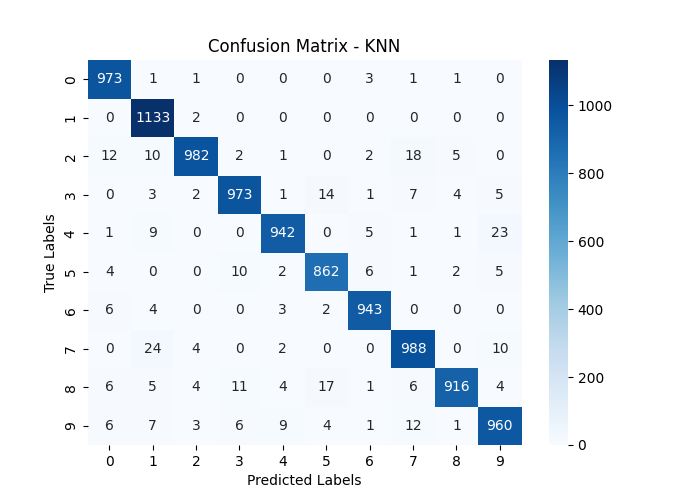

In [ ]:
# Confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - KNN")
plt.show()



> The baseline KNN model with **k=7** performed well in handwritten digit classification, achieving an overall accuracy of **96.72%** on the test set. With consistently high precision, recall, and F1-scores (**between 0.95 and 0.98**).



**Hyperparameter Tuning with GridSearchCV (KNN)**

Trying to adjust the n_neighbors parameter in order to determine the optimal accuracy value.

In [ ]:
from sklearn.model_selection import GridSearchCV

# Taking a subset of 10,000 samples from the original training data
x_sample = x_train[:10000]
y_sample = y_train[:10000]

param_grid = {
    'n_neighbors': list(range(1, 10)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn = KNeighborsClassifier()

# Setup GridSearchCV
grid = GridSearchCV(estimator=knn, param_grid=param_grid, cv=2, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit on training data
grid.fit(x_sample, y_sample)

Fitting 2 folds for each of 36 candidates, totalling 72 fits


GridSearchCV(cv=2, estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy', verbose=1)

In [ ]:
# Printing best parameters
print("Best Parameters:", grid.best_params_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'distance'}




> The optimal K-Nearest Neighbors (KNN) model, identified through GridSearchCV, uses **4** neighbors, the **Euclidean distance** metric, and **distance-based** weighting.




**Tuned KNN Evaluation**

In [ ]:
# Initializing the KNN model with best params
best_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='euclidean'
)

best_knn.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=4, weights='distance')

In [ ]:
y_pred_TunedKNN = best_knn.predict(x_test)
y_pred_TunedKNN

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [ ]:
# Accuracy of best_knn
accuracy = accuracy_score(y_test, y_pred_TunedKNN)
print(f"Test Accuracy of Tuned KNN: {accuracy * 100:.2f}%")

Test Accuracy of Tuned KNN: 97.10%


In [ ]:
# Classification report
print("\nClassification Report of Tuned KNN:\n", classification_report(y_test, y_pred_TunedKNN))


Classification Report of Tuned KNN:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.97      1.00      0.98      1135
           2       0.99      0.96      0.97      1032
           3       0.97      0.97      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.96      0.97      0.96       892
           6       0.98      0.99      0.98       958
           7       0.96      0.97      0.96      1028
           8       0.99      0.94      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



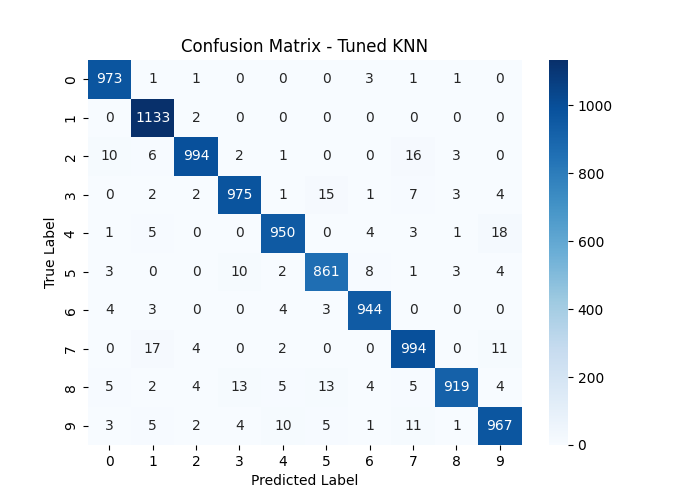

In [ ]:
# Confusion matrix
cm_best_knn = confusion_matrix(y_test, y_pred_TunedKNN)
plt.figure(figsize=(7,5))
sns.heatmap(cm_best_knn, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix - Tuned KNN')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()



> The tuned K-Nearest Neighbors (KNN) model achieved an impressive **97.10%** accuracy on the test set, with consistently high precision, ecall, and F1-scores across all digit classes. This demonstrates the model’s strong generalization capability for handwritten digit recognition.



### **Model 3: Support Vector Machine (SVM)**

In [ ]:
# Initializing the SVM model
svm_model = SVC()
svm_model.fit(x_train, y_train)

SVC()



> SVM model uses the default kernel (rbf), C=1.0, and gamma=‘scale’



In [ ]:
y_pred_svm = svm_model.predict(x_test)
y_pred_svm

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [ ]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\nTest Accuracy of SVM: {accuracy * 100:.2f}%")


Test Accuracy of SVM: 97.82%


In [ ]:
# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))


Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.98      0.98      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.97      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.97      0.97      1028
           8       0.97      0.98      0.97       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



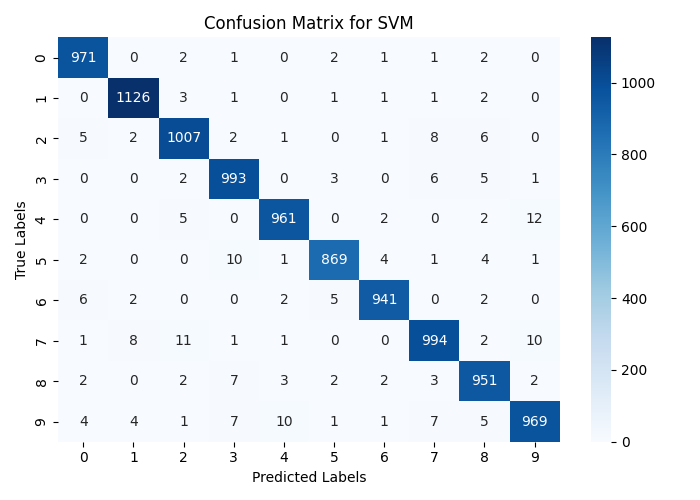

In [ ]:
# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=range(10), yticklabels=range(10))

plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.tight_layout()
plt.show()


> The baseline Support Vector Machine (SVM) model achieved a high accuracy of **97.82%** on the test set, with consistently strong precision, recall, and F1-scores (between 0.97-0.99) across all digit classes. This indicates the model’s excellent generalization capability and effectiveness in handwritten digit recognition.




## Comparing Model Performances

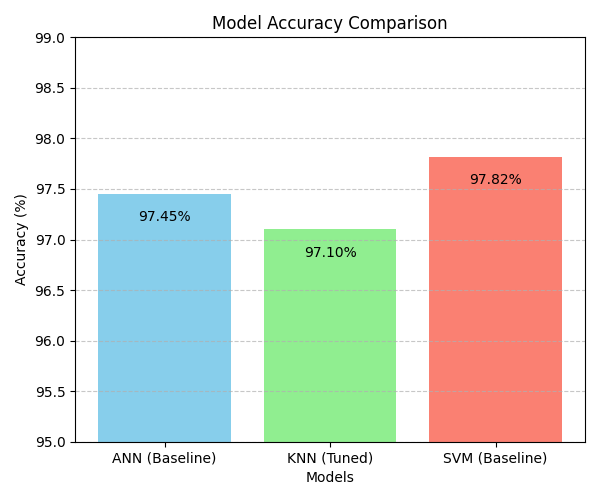

In [ ]:
# Model names and their corresponding accuracies
models = ['ANN (Baseline)', 'KNN (Tuned)', 'SVM (Baseline)']
accuracies = [97.51, 97.10, 97.82]

plt.figure(figsize=(6, 5))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'salmon'])
plt.ylim(95, 99)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.xlabel('Models')

# Annotating the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height - 0.3, f'{height:.2f}%', ha='center', va='bottom', fontsize=10, color='black')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




>  To conclude -
   - ANN showed strong performance with efficient training and low loss.
   - KNN benefitted significantly from hyperparameter tuning, matching closely with ANN in accuracy.
   - **SVM outperformed both ANN and KNN, making it the most effective model for this dataset in terms of accuracy.**







In [ ]:
from joblib import dump
from tensorflow.keras.models import save_model

# Save SVM and KNN (Scikit-learn models)
dump(svm_model, "svm_model.joblib")

['svm_model.joblib']

# GUI

In [ ]:
import tkinter as tk
from tkinter import *
import PIL.ImageGrab as ImageGrab
from PIL import Image, ImageOps
import numpy as np
from joblib import load

# Load trained model
model = load("svm_model.joblib")

def predict_digit(img):
    # resize to 28x28
    img = img.resize((28, 28))
    # grayscale
    img = img.convert('L')
    # invert (to match MNIST style)
    img = ImageOps.invert(img)
    # normalize
    img = np.array(img) / 255.0
    # flatten
    img = img.reshape(1, -1)
    # predict with trained model
    return model.predict(img)[0]

def clear_canvas():
    canvas.delete("all")

def classify_handwriting():
    # grab canvas image
    x = root.winfo_rootx() + canvas.winfo_x()
    y = root.winfo_rooty() + canvas.winfo_y()
    x1 = x + canvas.winfo_width()
    y1 = y + canvas.winfo_height()

    # take screenshot of the canvas region
    img = ImageGrab.grab().crop((x, y, x1, y1))

    # pass the image to predictor
    digit = predict_digit(img)

    # show result
    label.config(text="Prediction: " + str(digit))

# GUI setup
root = Tk()
root.resizable(0, 0)
root.title("Handwritten Digit Recognition")

canvas = Canvas(root, width=200, height=200, bg="white")
canvas.grid(row=0, column=0, pady=2, sticky=W, columnspan=2)

label = Label(root, text="Prediction: ", font=("Helvetica", 16))
label.grid(row=1, column=0, pady=2, padx=2)

btn_predict = Button(root, text="Predict", command=classify_handwriting)
btn_predict.grid(row=2, column=0, pady=2, padx=2)

btn_clear = Button(root, text="Clear", command=clear_canvas)
btn_clear.grid(row=2, column=1, pady=2, padx=2)

def paint(event):
    x1, y1 = (event.x - 8), (event.y - 8)
    x2, y2 = (event.x + 8), (event.y + 8)
    canvas.create_oval(x1, y1, x2, y2, fill="black", width=10)

canvas.bind("<B1-Motion>", paint)

root.mainloop()

The developed **Tkinter-based GU**I provides an interactive platform for handwritten digit recognition, where users can draw digits on a canvas, and upon submission, the input is captured, preprocessed to match the MNIST format, and classified using the trained machine learning model - **SVM** , with the predicted output displayed on the interface.

# Challenges

**GUI**: The main challenge faced was working with Tkinter for GUI development, as it was new and initially difficult to integrate with the trained models. This led to errors in callbacks and event handling.  

> The issue was resolved by learning Tkinter basics, experimenting with examples, and gradually linking the canvas with preprocessing and prediction. This helped in successfully building an interactive GUI and gaining hands-on experience with Python GUI development.

# Project Summary

```
The project successfully implemented three machine learning models—ANN, KNN,
and SVM—for handwritten digit recognition. Among these, SVM demonstrated the
highest accuracy, outperforming both ANN and KNN, with KNN showing notable
improvement after hyperparameter tuning. The GUI application built using
Tkinter provides an interactive platform where users can draw digits and
instantly receive predictions from the trained model. This integration not only
demonstrates the practical deployment of machine learning models but also
enhances user accessibility by bridging the gap between model development and real-world application.
```